# Relatório de Modelagem: Dados de Churn

### Objetivo

Avaliar fatores que impactam na probabilidade de churn dos clientes

### Resultados

In [1]:
# importando bibliotecas

import numpy as np 
import pandas as pd 
pd.set_option('display.max_columns', None) # show all columns
pd.set_option('display.max_rows', None) # show all rows
import matplotlib.pyplot as plt
import seaborn as sns 
import shap

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, log_loss, classification_report, roc_auc_score, auc, roc_curve, confusion_matrix
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [28]:
# Carregar banco de dados
full_data = pd.read_excel('data/raw_data.xlsx', index_col='customerID')
# fazendo um data split aleatório de 70/30
X = full_data.drop('Churn', axis=1)
y = full_data['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y,train_size=0.7, random_state=45641564)

Split de dados 70/30 para treinamento/teste.

In [3]:
# Criando pipeline de preprocessamento de dados

## Selecionando features numéricas e categóricas
numerical_ix = X_train.select_dtypes(include=np.number).columns
categorical_ix = X_train.select_dtypes(exclude=np.number).columns

## Pipelines para cada tipo de dado
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())])

categorical_transformer = Pipeline(steps=[
    ('encoder', OrdinalEncoder()),
    ('scaler', StandardScaler())])

## Juntando pipelines
preprocessor = ColumnTransformer([
        ('numerical', numerical_transformer, numerical_ix),
        ('categorical', categorical_transformer, categorical_ix)],
         remainder='passthrough')

Para o pré-processamento de dados, as features categóricas foram encodadas, para permitir o seu uso em quaisquer algoritmo, e todas as features foram padronizadas, para aumentar a eficácia dos métodos de classificação.

Text(0, 0.5, 'Test AUC')

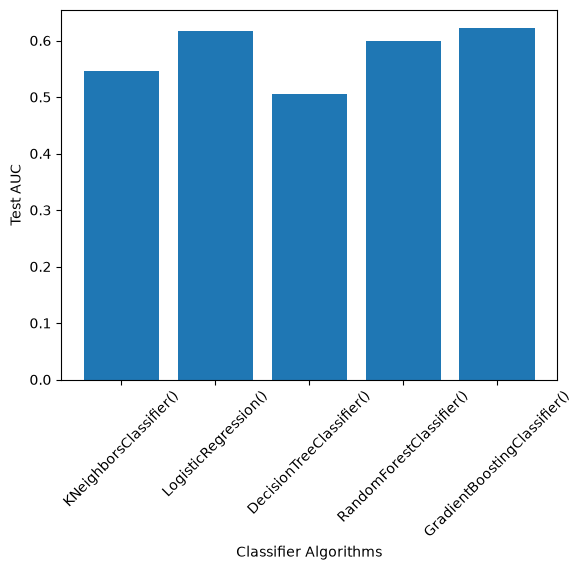

In [4]:
# selecionando algoritmos para comparação

## Lista de algoritmos a serem comparados
classifiers = [
    KNeighborsClassifier(),
    LogisticRegression(random_state=123),
    DecisionTreeClassifier(random_state=123),
    RandomForestClassifier(random_state=123),
    GradientBoostingClassifier(random_state=123)
    ]

classifier_names = [
    'KNeighborsClassifier()',
    'LogisticRegression()',
    'DecisionTreeClassifier()',
    'RandomForestClassifier()',
    'GradientBoostingClassifier()'
]

model_scores = []

## loop para calcular o AUC de teste de cada um
for classifier, name in zip(classifiers, classifier_names):
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('selector', SelectKBest(k=len(X_train.columns))),
        ('classifier', classifier)])
    pipe.fit(X_train,y_train)
    y_probs = pipe.predict_proba(X_test)[:, 1]
    score = roc_auc_score(y_test, y_probs)
    model_scores.append(score)

## gráfico de barras com o AUC de cada um
plt.bar(classifier_names, model_scores)
plt.xlabel('Classifier Algorithms')
plt.xticks(classifier_names, rotation=45) 
plt.ylabel('Test AUC')

In [5]:
# tabela com os valores de AUC por modelo
model_performance = pd.DataFrame({
    'Classifier': 
      classifier_names, 
    'Test AUC':
      model_scores
})

sorted_models = model_performance.sort_values('Test AUC', ascending = False, ignore_index=True)
display(sorted_models)
## separando modelo com o melhor resultado
best_model = eval(sorted_models['Classifier'][0])

,Classifier,Test AUC
0,GradientBoostingClassifier(),0.623011
1,LogisticRegression(),0.616254
2,RandomForestClassifier(),0.598613
3,KNeighborsClassifier(),0.545500
4,DecisionTreeClassifier(),0.505770


Foram escolhidos para serem avaliados os modelos logistico, Random Forest, k-nearest neighbors, GradientBoosting e DecisionTree. Após rodar todos nos dados de treinamento e calcular as AUCs resultantes nos dados de teste, temos que o melhor modelo identificado foi o GradientBoosting, com uma AUC de 0.623. Todos foram rodados com seus hiper parâmetros  padrões. Para as features, foi utilizado o SelectKBest, que seleciona as features com os melhores resultados para cada modelo.

In [6]:
# pipeline para a seleção de hiper parametros

param_pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('selector', SelectKBest(k=len(X.columns))),
        ('classifier', best_model)
])

In [7]:
# valores a serem testados
grid = {
    "selector__k": [13,14,15,16,17,18],
    "classifier__max_depth":[1,3,5],
    "classifier__learning_rate":[0.01,0.1,1],
    "classifier__n_estimators":[100,200,300,400]
}

# função pora testar cada combinação usando AUC de validação cruzada nos dados treinamento
gridsearch = GridSearchCV(estimator=param_pipe, param_grid=grid, n_jobs= 1, scoring='roc_auc')
gridsearch.fit(X_train,y_train)  

# Resultados (melhores parametros e melhor score)
print(gridsearch.best_params_) 
print(gridsearch.best_score_) 

{'classifier__learning_rate': 0.1, 'classifier__max_depth': 1, 'classifier__n_estimators': 100, 'selector__k': 13}
0.6233893633120744


Utilizando um algoritmo de gridsearch com alguns candidatos e utilizando como critério a AUC de validação cruzada nos dados treinamento, foram estabelecidos os hiper parâmetros ótimos do GradientBoosting, com learning_rate igual a 0.1, max_depth igual a 1 e n_estimators igual a 100. Também foi avaliado o melhor parâmetro k para seleção de features, que resultou no valor de 13.

In [8]:
# pipeline final do modelo
end_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', SelectKBest(k=13)), 
    ('classifier', best_model)])\
    .fit(X_train,y_train)

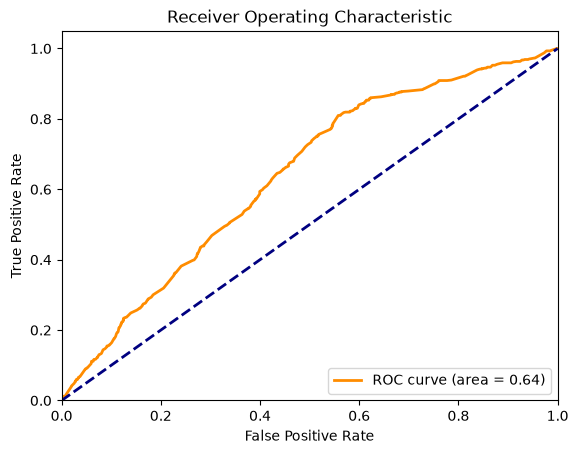

In [9]:
# Ajustando o modelo com os melhores parametros
gridsearch.refit

# Fazendo predição dos dados de teste
y_pred = gridsearch.predict(X_test)

y_probs = gridsearch.predict_proba(X_test)[:, 1]

# Gerando curva ROC e AUC
y_test_re = y_test == "Yes"
fpr, tpr, thresholds = roc_curve(y_test_re, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [10]:
# Matriz de confusão do modelo
print(confusion_matrix(y_test, y_pred,normalize = 'true'))

[[0.99709513 0.00290487]
 [0.99320652 0.00679348]]


In [11]:
# Report da classificação avaliando precision, recall, f1 e acurácia
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.65      1.00      0.79      1377
         Yes       0.56      0.01      0.01       736

    accuracy                           0.65      2113
   macro avg       0.60      0.50      0.40      2113
weighted avg       0.62      0.65      0.52      2113



A AUC final de 0.64 modelo fraco, que pode ou não ser útil dependendo do uso, porém ao analisarmos a precision e o recall para as categorias de churn, vemos que o modelo fracassa em classificar possíveis casos de churn, com toda a sua acurácia sendo baseada em acertar os casa onde não houve churn, resultado em um valor de 65%, quase igual a proporção de 'não's na variável churn. Podemos confirma esse resultado ao ver que a proporção de positivos reais e negativos falsos são ambos quase iguais a um.

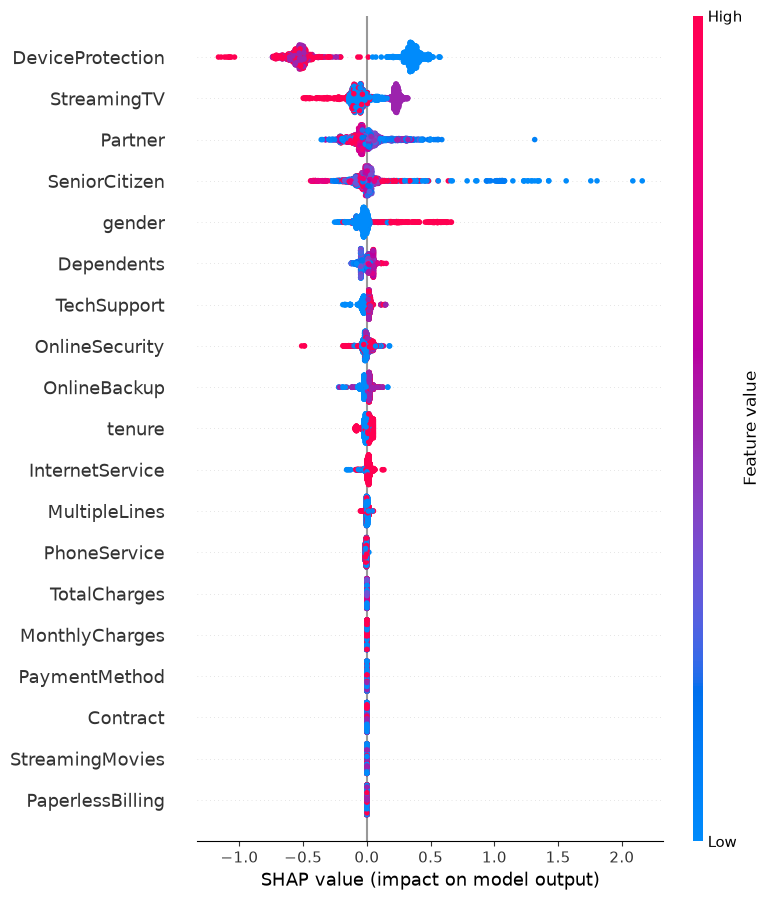

In [12]:
# Transformando dados teste pela pipeline
X_test_proc = end_pipe.named_steps['preprocessor'].transform(X_test)

# Calculando shap values para as features do modelo
explainer = shap.Explainer(end_pipe["classifier"])
shap_values = explainer.shap_values(X_test_proc)

# Plotando os shap values de acordo com o valor de cada feature 
shap.summary_plot(shap_values, X_test_proc, feature_names = X_test.columns)

Text(0, 0.5, 'Features')

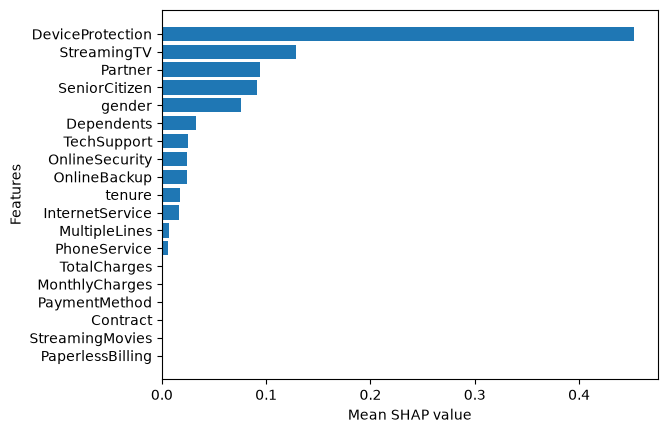

In [13]:
# Calculando shap value médio de cada feature
mean_abs_shap_values = np.abs(shap_values).mean(axis=0)
data = {
    'Feature': X_test.columns,
    'Mean Importance': mean_abs_shap_values
}
df = pd.DataFrame(data)
df = df.sort_values(by='Mean Importance')

## plotando valores num gráfico de barras
plt.barh(df['Feature'], df['Mean Importance'])
plt.xlabel('Mean SHAP value')
plt.yticks(X_test.columns) 
plt.ylabel('Features')

Através da análise de SHAP values, podemos perceber a importância de cada feature para o modelo, e de que forma esse impacto se comporta. De longe, olhando pela média, a feature mais importante foi a contratação ou não de proteção de dispositivos, com aqueles que não contratam esse serviço tendo uma maior chance churn. Bem abaixo no impacto temos a contratação de streming de televisão, seguida da existência de um parceiro(a), se o cliente é idoso e o gênero do cliente. É importante apontar que várias features ficaram um impacto praticamente nulo na classificação e que o efeito absoluto em geral foi baixo mesmo para aquela que tiveram maior impacto.

### Conclusão

No fim, a modelagem do problema proposta é limitada pelos dados existentes, pois eles apresentam informação para que seja possível uma boa e robusta previsão de churn dos clientes. Alguns insights podem ser extraídos dos resultados, principalmente a falta de impacto de algumas features, como tempo de contrato, gasto mensal e frequência de pagamentos. Também é importante notar a importância tímida alguns fatores, principalmente a contratação do serviço de proteção de dispositivos.